напишите Python-скрипт для создания таблицы в PostgreSQL и загрузки в нее данных из вашего CSV-файла. это имитирует наличие данных в операционной реляционной СУБД.

In [5]:
import pandas as pd
from sqlalchemy import create_engine

DB_USER = "postgres"
DB_PASS = "123"
DB_NAME = "lab5_db"
DB_HOST = "localhost"
DB_PORT = "5432"

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

csv_path = "/Users/sofia/Desktop/AB_NYC_2019.csv"
df = pd.read_csv(csv_path)

print("Строк:", len(df))

df.to_sql("airbnb", engine, if_exists="replace", index=False)

print("Данные успешно загружены!")


Строк: 48895
Данные успешно загружены!


,neighbourhood_group,listing_count,avg_price
0,Bronx,87.50,1091
1,Brooklyn,124.39,20103
2,Manhattan,196.88,21661
3,Queens,99.52,5666
4,Staten Island,114.81,373


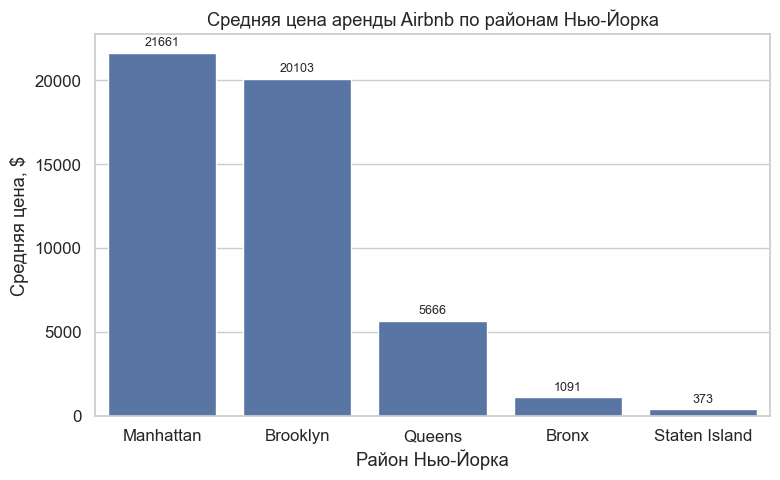

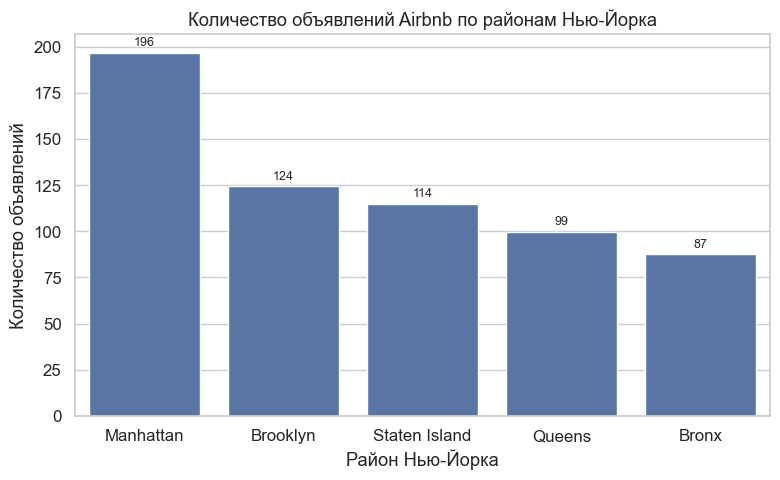

In [6]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Стиль
sns.set(style="whitegrid", font_scale=1.1)

# Путь к результатам MapReduce
base_dir = os.path.expanduser("~/hadoop-lab-5/output_price_by_area")
result_path = os.path.join(base_dir, "part-00000")

# Загружаем результат: район, количество объявлений, средняя цена
df = pd.read_csv(
    result_path,
    sep="\t",
    header=None,
    names=["neighbourhood_group", "listing_count", "avg_price"]
)

display(df)

# --- График 1. Средняя цена ---
order_price = df.sort_values("avg_price", ascending=False)["neighbourhood_group"]

plt.figure(figsize=(8, 5))
ax1 = sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="avg_price",
    order=order_price
)
ax1.set_xlabel("Район Нью-Йорка")
ax1.set_ylabel("Средняя цена, $")
ax1.set_title("Средняя цена аренды Airbnb по районам Нью-Йорка")

for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f"{height:.0f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

# --- График 2. Количество объявлений ---
order_count = df.sort_values("listing_count", ascending=False)["neighbourhood_group"]

plt.figure(figsize=(8, 5))
ax2 = sns.barplot(
    data=df,
    x="neighbourhood_group",
    y="listing_count",
    order=order_count
)
ax2.set_xlabel("Район Нью-Йорка")
ax2.set_ylabel("Количество объявлений")
ax2.set_title("Количество объявлений Airbnb по районам Нью-Йорка")

for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f"{int(height):,}".replace(",", " "),
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=9,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()
